**Practica 4**:  Procesamiento geométrico y procesamiento de histograma

**Parte I.- Procesamiento geométrico**

Ejercicio 1: Traslación

1. Cargar una imagen médica en escala de grises (puede ser una radiografía o resonancia magnética).

2. Aplicar una traslación de (50, 30) píxeles en la dirección (x, y).

3. Aplicar una traslación con valores decimales, por ejemplo, (20.5, 15.5) píxeles.

4. Mostrar la imagen original y las imágenes transformadas.

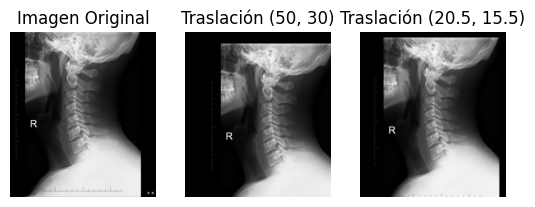

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen en grises
img = cv2.imread('radiografia cuello.jpg', 0)

# Tamaño de la imagen
filas, columnas = img.shape

# Traslación (50, 30)
M1 = np.float32([[1, 0, 50],
                 [0, 1, 30]])

img1 = cv2.warpAffine(img, M1, (columnas, filas))

# Traslación decimal (20.5, 15.5)
M2 = np.float32([[1, 0, 20.5],
                 [0, 1, 15.5]])

img2 = cv2.warpAffine(img, M2, (columnas, filas))

# Mostrar imágenes
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img1, cmap='gray')
plt.title('Traslación (50, 30)')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img2, cmap='gray')
plt.title('Traslación (20.5, 15.5)')
plt.axis('off')

plt.show()

Ejercicio 2: Rotación

1. Aplicar una rotación de 45° alrededor del centro de la imagen.

2. Mostrar la imagen original y la imagen rotada.

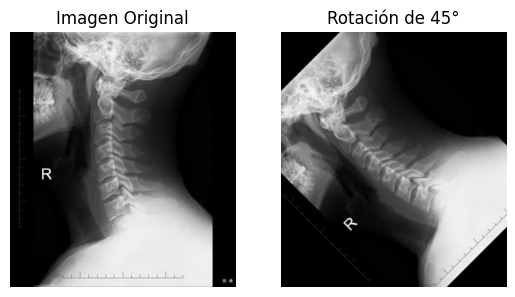

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen en grises
img = cv2.imread('radiografia cuello.jpg', 0)

# Obtener tamaño
filas, columnas = img.shape

# Centro de la imagen
centro = (columnas // 2, filas // 2)

# Rotación de 45 grados
M = cv2.getRotationMatrix2D(centro, 45, 1)

img_rotada = cv2.warpAffine(img, M, (columnas, filas))

# Mostrar imágenes
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_rotada, cmap='gray')
plt.title('Rotación de 45°')
plt.axis('off')

plt.show()

Ejercicio 3: Escala

1. Aplicar un escalado al 150% de tamaño y otro al 50% de tamaño.

2. Mostrar la imagen original y los resultados de escalas.

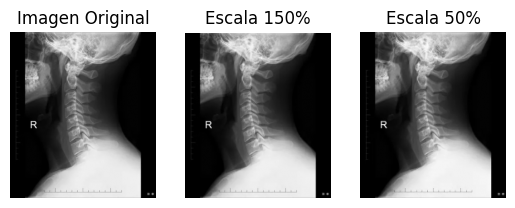

In [6]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen en grises
img = cv2.imread('radiografia cuello.jpg', 0)

# Escala al 150%
img_grande = cv2.resize(img, None, fx=1.5, fy=1.5)

# Escala al 50%
img_pequena = cv2.resize(img, None, fx=0.5, fy=0.5)

# Mostrar imágenes
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_grande, cmap='gray')
plt.title('Escala 150%')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_pequena, cmap='gray')
plt.title('Escala 50%')
plt.axis('off')

plt.show()

**Parte II.- Ecualización de histograma**

Ejercicio 1: Ecualización.

1. Cargar una imagen médica con bajo contraste.

2. Obtener y visualizar el histograma de la imagen original.

3. Aplicar ecualización de histograma para mejorar el contraste.

4. Mostrar la imagen original, la imagen mejorada y comparar los histogramas.

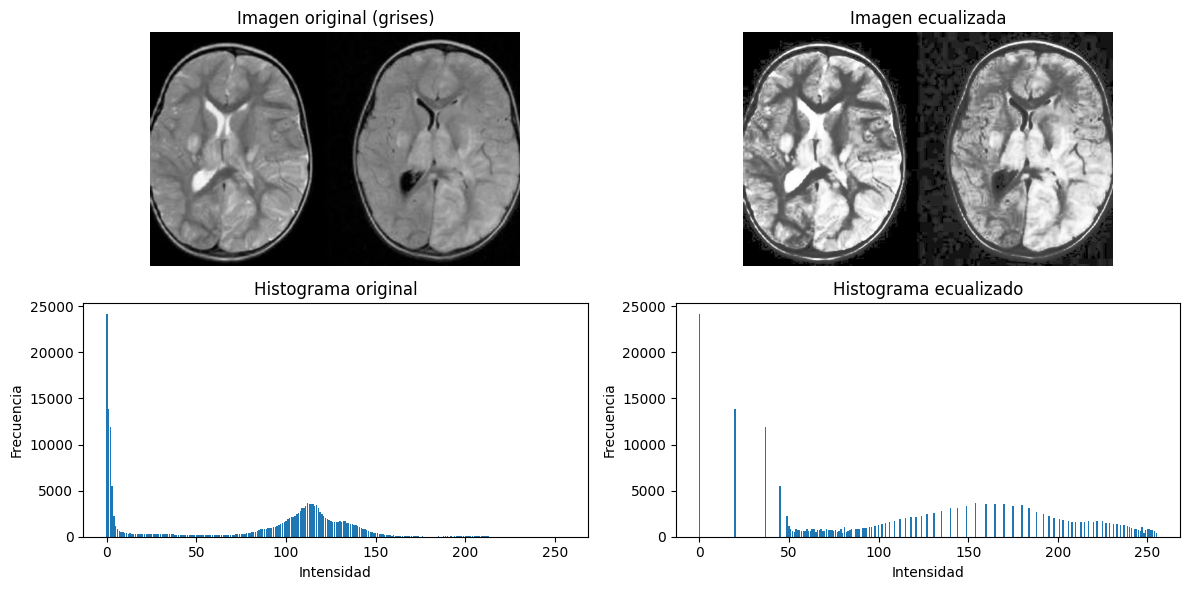

In [9]:
import cv2
import matplotlib.pyplot as plt

# 1. Cargar imagen
img = cv2.imread('resonancia.jpg')

# Convertir de BGR a RGB (para mostrar bien en matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Convertir a escala de grises
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 3. Calcular histograma original
hist_original = cv2.calcHist([gray], [0], None, [256], [0,256])

# 4. Ecualizar imagen
img_eq = cv2.equalizeHist(gray)

# 5. Calcular histograma ecualizado
hist_eq = cv2.calcHist([img_eq], [0], None, [256], [0,256])

# 6. Mostrar resultados
plt.figure(figsize=(12,6))

# Imagen original
plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Imagen original (grises)')
plt.axis('off')

# Imagen ecualizada
plt.subplot(2,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title('Imagen ecualizada')
plt.axis('off')

# Histograma original
plt.subplot(2,2,3)
plt.bar(range(256), hist_original.ravel())
plt.title('Histograma original')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Histograma ecualizado
plt.subplot(2,2,4)
plt.bar(range(256), hist_eq.ravel())
plt.title('Histograma ecualizado')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()